In [39]:
#Struktur på data
import pandas as pd

df = pd.read_csv("housing.csv")

print("Form:", df.shape)
print("\nFörsta raderna:\n", df.head())
print("\nInfo:")
df.info()
print("\nSammanfattning:\n", df.describe())


Form: (20640, 10)

Första raderna:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value ocean_proximity
0    -122.23     37.88                41.0        880.0           129.0       322.0       126.0         8.3252            452600.0        NEAR BAY
1    -122.22     37.86                21.0       7099.0          1106.0      2401.0      1138.0         8.3014            358500.0        NEAR BAY
2    -122.24     37.85                52.0       1467.0           190.0       496.0       177.0         7.2574            352100.0        NEAR BAY
3    -122.25     37.85                52.0       1274.0           235.0       558.0       219.0         5.6431            341300.0        NEAR BAY
4    -122.25     37.85                52.0       1627.0           280.0       565.0       259.0         3.8462            342200.0        NEAR BAY

Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data colum

In [40]:
# Data kvalité
import pandas as pd

df = pd.read_csv("housing.csv")

print("Saknade värden:\n", df.isna().sum())
print("\nDubbletter:", df.duplicated().sum())


Saknade värden:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Dubbletter: 0



Närhet till havet:
 ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


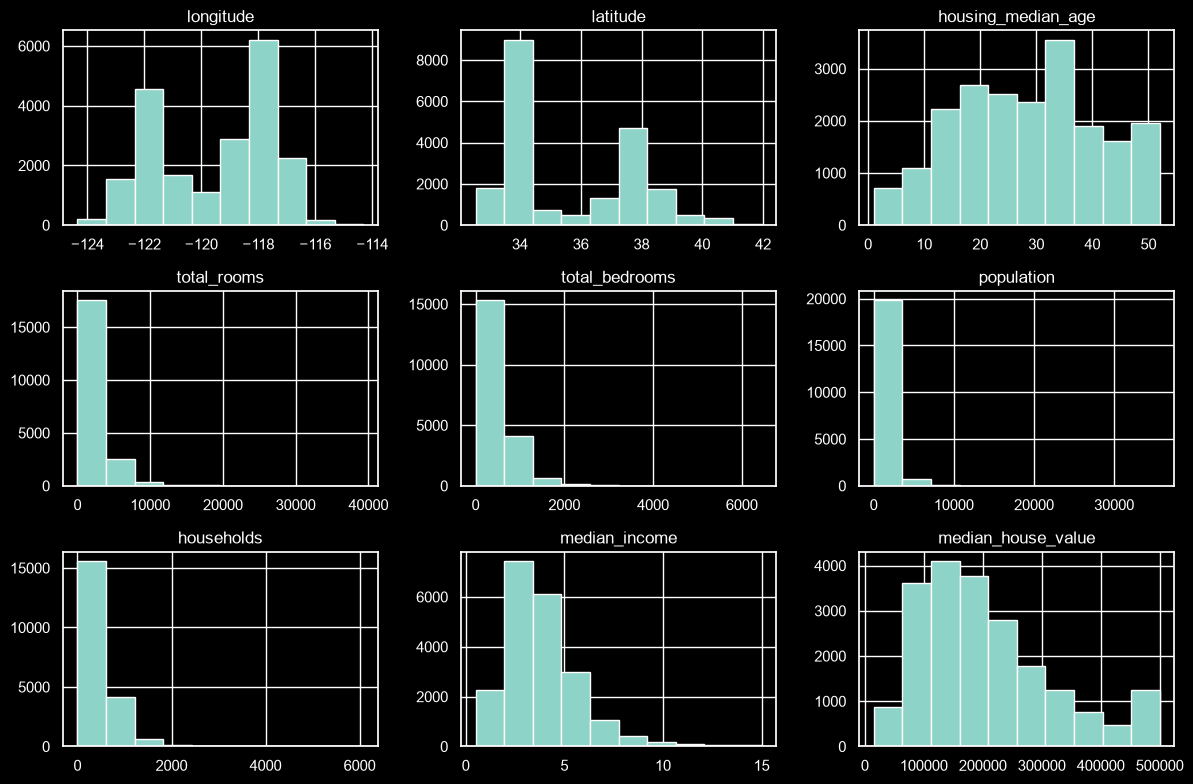

In [64]:
#Histogram, har inte tagit hänsyn till att longitude/latitud som hänger ihop, man skulle kunna placera värdena på en karta
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("housing.csv")

df.hist(figsize=(12, 8))
plt.tight_layout()
print("\nNärhet till havet:\n", df["ocean_proximity"].value_counts())


Jämförs  med median_house_value :
 median_house_value    1.00
median_income         0.69
total_rooms           0.13
housing_median_age    0.11
households            0.07
total_bedrooms        0.05
population           -0.02
longitude            -0.05
latitude             -0.14
Name: median_house_value, dtype: float64

Medianpris per ocean_proximity:
 ocean_proximity
INLAND        108500.0
<1H OCEAN     214850.0
NEAR OCEAN    229450.0
NEAR BAY      233800.0
ISLAND        414700.0
Name: median_house_value, dtype: float64


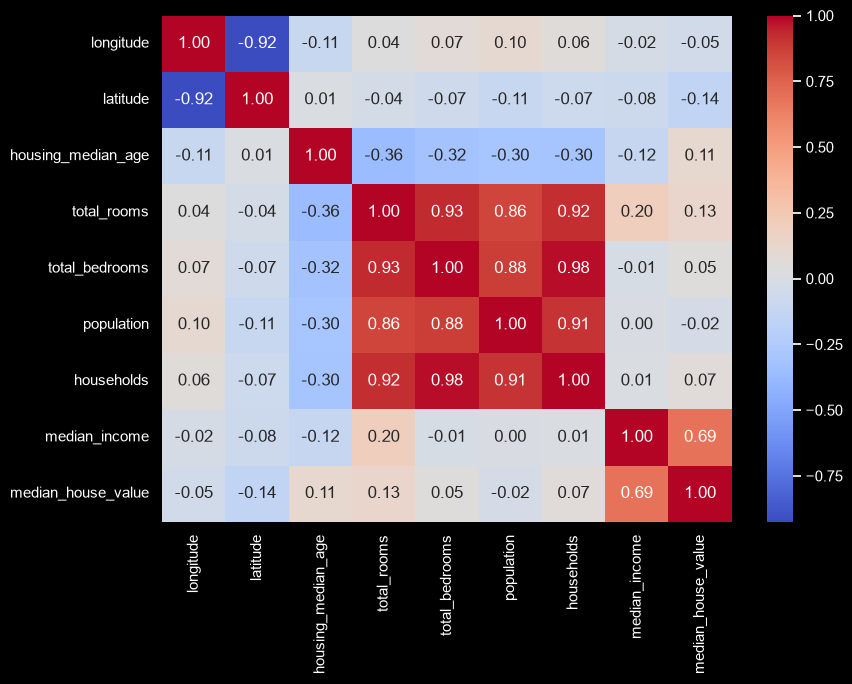

In [68]:
# Är värdet 1 så är värdena lika, ju längre från 1 desto längre från är värdena
# Till exempel badrum och rum är ganska nära varandra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("housing.csv")
TARGET = "median_house_value"

korr = df.corr(numeric_only=True)[TARGET].sort_values(ascending=False)
print("Jämförs  med", TARGET, ":\n", korr.round(2))


plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()

# Medianpris per kategori
print("\nMedianpris per ocean_proximity:\n",
      df.groupby("ocean_proximity")[TARGET].median().sort_values())

Antal outliers per kolumn:
longitude                0
latitude                 0
housing_median_age       0
total_rooms           1287
total_bedrooms        1271
population            1196
households            1220
median_income          681
median_house_value    1071
dtype: int64


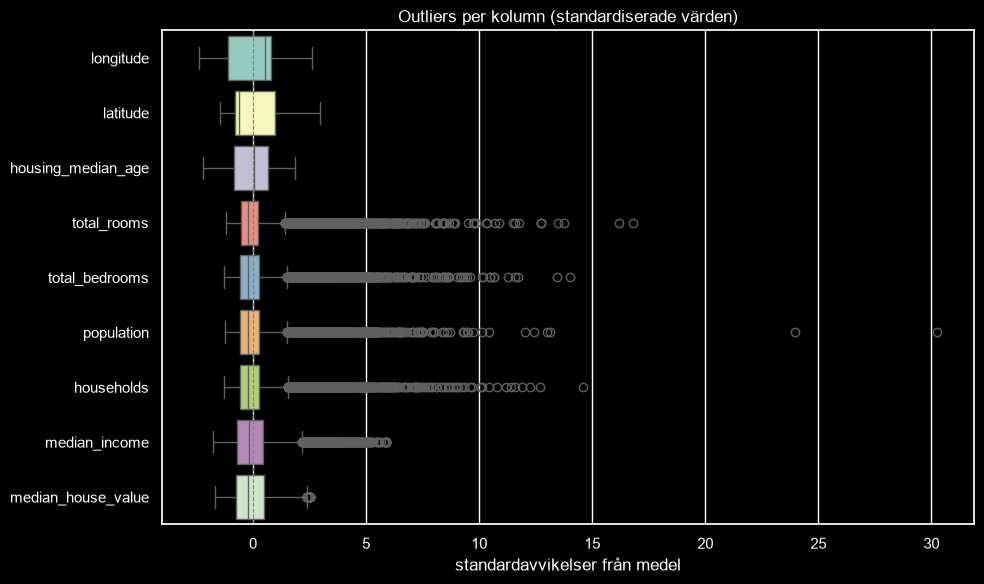

In [45]:
# Ju längre ut på högerkanten desto mer avviker värdet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("housing.csv")
num = df.select_dtypes("number")

# outliers sticker ut till höger
z = (num - num.mean()) / num.std()
plt.figure(figsize=(10, 6))
sns.boxplot(data=z, orient="h")
plt.axvline(0, color="gray", lw=0.8, ls="--")
plt.title("Outliers per kolumn (standardiserade värden)")
plt.xlabel("standardavvikelser från medel")
plt.tight_layout()

q1, q3 = num.quantile(0.25), num.quantile(0.75)
iqr = q3 - q1
outliers = ((num < q1 - 1.5 * iqr) | (num > q3 + 1.5 * iqr)).sum()
print("Antal outliers per kolumn:")
print(outliers)
